<a href="https://colab.research.google.com/github/vaniajou/Sistem-Peringatan-Dini-Kegagalan-Siswa/blob/main/Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Memulai proses training...


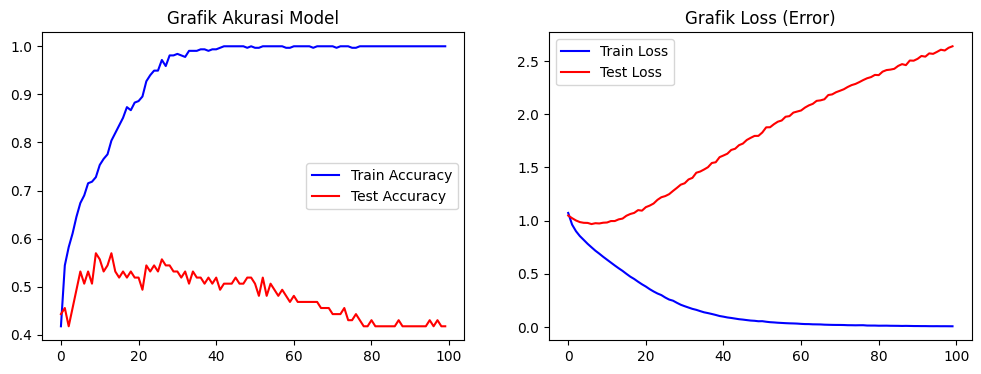

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


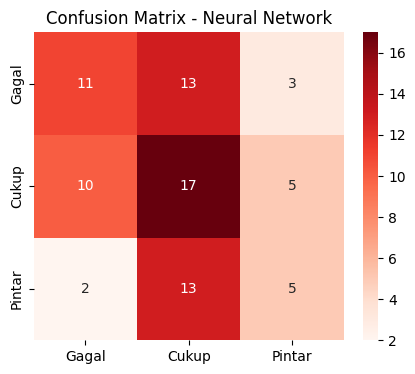

Akurasi Akhir Neural Network: 0.42


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

df = pd.read_excel('Book1.xlsx')

def buat_label(nilai):
    if nilai <= 9: return 0
    elif nilai <= 14: return 1
    else: return 2

df['Label_Multi'] = df['G3'].apply(buat_label)
df_model = df.drop(['G1', 'G2', 'G3', 'Label_Multi'], axis=1)

le = LabelEncoder()
for col in df_model.columns:
    if df_model[col].dtype == 'object':
        df_model[col] = le.fit_transform(df_model[col])

X = df_model.values
y = df['Label_Multi'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Memulai proses training...")
history = model.fit(X_train, y_train, epochs=100, batch_size=16,
                    validation_data=(X_test, y_test), verbose=0)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Test Accuracy', color='red')
plt.title('Grafik Akurasi Model')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Test Loss', color='red')
plt.title('Grafik Loss (Error)')
plt.legend()
plt.show()

y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Gagal', 'Cukup', 'Pintar'],
            yticklabels=['Gagal', 'Cukup', 'Pintar'])
plt.title('Confusion Matrix - Neural Network')
plt.show()

print(f"Akurasi Akhir Neural Network: {history.history['val_accuracy'][-1]:.2f}")